In [1]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px

prices = pd.read_csv("../data/dax_prices.csv")
fin_df = pd.read_csv("../data/dax_financials.csv")

print("Datos cargados OK")
print(f"Empresas: {len(fin_df)}")
print(f"Sectores: {fin_df['sector'].unique()}")

Datos cargados OK
Empresas: 20
Sectores: <StringArray>
['Industrials',   'Chemicals',  'Automotive',  'Financials',  'Technology',
    'Consumer',  'Healthcare',   'Logistics']
Length: 8, dtype: str


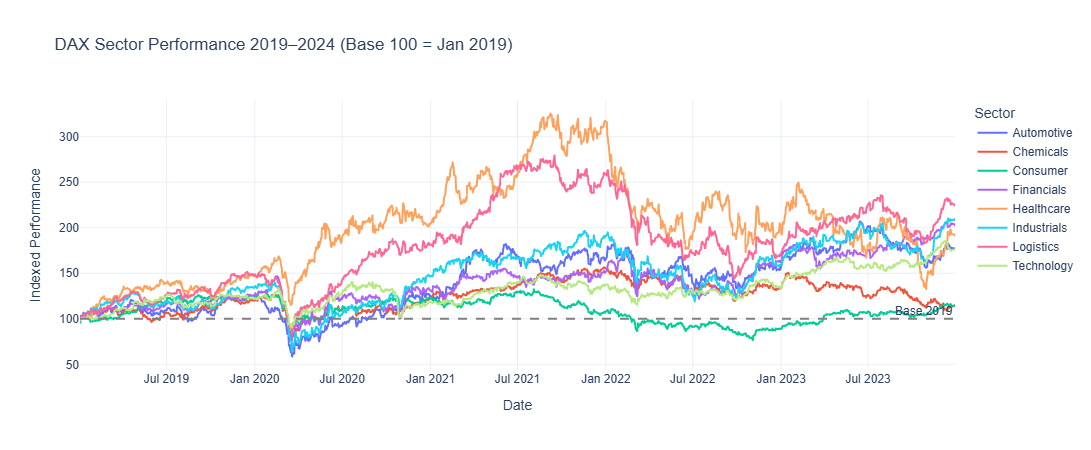

In [2]:
prices["date"] = pd.to_datetime(prices["date"])
prices = prices.sort_values(["company", "date"])

# Base 100 = Enero 2019
base = prices.groupby("company").first()["close"]
prices["close_norm"] = prices.apply(
    lambda r: r["close"] / base[r["company"]] * 100, axis=1
)

# Performance promedio por sector
sector_perf = prices.groupby(["date", "sector"])["close_norm"].mean().reset_index()

fig = px.line(
    sector_perf,
    x="date",
    y="close_norm",
    color="sector",
    title="DAX Sector Performance 2019–2024 (Base 100 = Jan 2019)",
    labels={"date": "Date", "close_norm": "Indexed Performance", "sector": "Sector"},
)

fig.add_hline(y=100, line_dash="dash", line_color="gray",
              annotation_text="Base 2019")

fig.update_layout(
    template="plotly_white",
    font=dict(family="Arial", size=12),
    hovermode="x unified",
    height=450
)

fig.show()

In [3]:
# Medir caída en COVID (Mar 2020) y recuperación
prices["year_month"] = prices["date"].dt.to_period("M")

# Pre-COVID: Enero 2020
# COVID trough: Marzo 2020
# Recovery: Diciembre 2021

def get_avg_perf(df, year, month):
    mask = (df["date"].dt.year == year) & (df["date"].dt.month == month)
    return df[mask].groupby("company")["close_norm"].mean()

pre_covid  = get_avg_perf(prices, 2020, 1)
trough     = get_avg_perf(prices, 2020, 3)
recovery   = get_avg_perf(prices, 2021, 12)
current    = get_avg_perf(prices, 2023, 12)

covid_df = pd.DataFrame({
    "pre_covid":  pre_covid,
    "trough":     trough,
    "recovery":   recovery,
    "current":    current,
}).reset_index()

covid_df = covid_df.merge(
    fin_df[["company", "sector"]], on="company", how="left"
)

covid_df["covid_drop_pct"]     = ((covid_df["trough"]   - covid_df["pre_covid"]) / covid_df["pre_covid"] * 100).round(1)
covid_df["recovery_pct"]       = ((covid_df["recovery"] - covid_df["trough"])    / covid_df["trough"]    * 100).round(1)
covid_df["total_return_pct"]   = ((covid_df["current"]  - 100) ).round(1)

print("COVID Impact & Recovery by Company:")
print(covid_df[["company", "sector", "covid_drop_pct",
                "recovery_pct", "total_return_pct"]].sort_values(
                "total_return_pct", ascending=False).to_string(index=False))

COVID Impact & Recovery by Company:
         company      sector  covid_drop_pct  recovery_pct  total_return_pct
       Sartorius  Healthcare            -2.1         183.9             197.5
       Munich Re  Financials           -28.5          43.2             152.0
   Deutsche Post   Logistics           -31.0         146.2             127.3
        Infineon Industrials           -30.3         179.4             125.7
   Mercedes-Benz  Automotive           -38.3         211.0             121.0
         Siemens Industrials           -31.8         123.3             119.3
             BMW  Automotive           -33.0         101.5              90.4
Deutsche Telekom  Technology           -14.5          37.2              80.1
             SAP  Technology           -18.9          25.2              80.0
   Deutsche Bank  Financials           -21.7          83.7              79.7
         Allianz  Financials           -27.7          42.9              77.9
          Airbus Industrials           -

In [4]:
# Limpiar métricas
fin_clean = fin_df.copy()
fin_clean["gross_margins"]    = (fin_clean["gross_margins"]    * 100).round(1)
fin_clean["profit_margins"]   = (fin_clean["profit_margins"]   * 100).round(1)
fin_clean["return_on_equity"] = (fin_clean["return_on_equity"] * 100).round(1)
fin_clean["revenue_growth"]   = (fin_clean["revenue_growth"]   * 100).round(1)

# Agregar por sector
sector_kpis = fin_clean.groupby("sector").agg(
    avg_gross_margin  = ("gross_margins",    "mean"),
    avg_profit_margin = ("profit_margins",   "mean"),
    avg_roe           = ("return_on_equity", "mean"),
    avg_ev_ebitda     = ("ev_ebitda",        "mean"),
    avg_revenue_growth= ("revenue_growth",   "mean"),
).round(1).reset_index()

print("Sector KPI Benchmarking:")
print(sector_kpis.to_string(index=False))

Sector KPI Benchmarking:
     sector  avg_gross_margin  avg_profit_margin  avg_roe  avg_ev_ebitda  avg_revenue_growth
 Automotive              14.2                3.7      5.2           10.8                -5.2
  Chemicals              47.4                3.4      2.0           10.7                -2.7
   Consumer              53.3                8.3     14.6           11.3                 0.2
 Financials              20.1               14.7     15.7            6.9                 1.3
 Healthcare              35.4                5.5      7.0           17.0                 1.9
Industrials              31.8                7.9     12.9           23.6                -3.3
  Logistics              17.5                4.2     15.6           10.8                -1.9
 Technology              59.1               13.4     15.4           10.4                 3.2


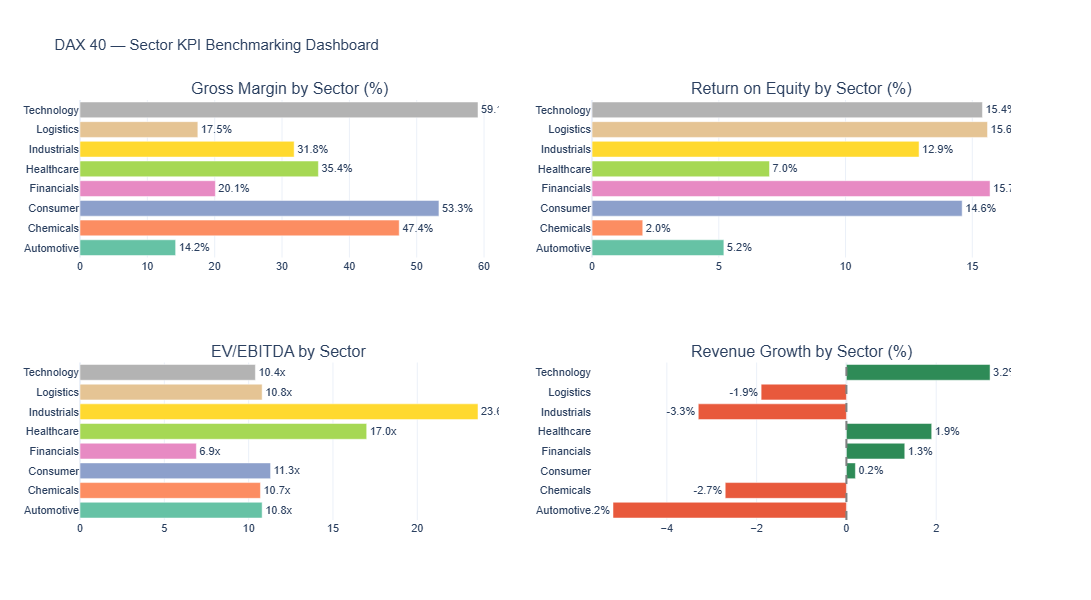

In [5]:
fig2 = make_subplots(rows=2, cols=2,
    subplot_titles=(
        "Gross Margin by Sector (%)",
        "Return on Equity by Sector (%)",
        "EV/EBITDA by Sector",
        "Revenue Growth by Sector (%)"
    ))

sectors   = sector_kpis["sector"]
colors    = px.colors.qualitative.Set2[:len(sectors)]

# 1. Gross margin
fig2.add_trace(go.Bar(
    x=sector_kpis["avg_gross_margin"],
    y=sectors, orientation="h",
    marker_color=colors, showlegend=False,
    text=sector_kpis["avg_gross_margin"].astype(str) + "%",
    textposition="outside"
), row=1, col=1)

# 2. ROE
fig2.add_trace(go.Bar(
    x=sector_kpis["avg_roe"],
    y=sectors, orientation="h",
    marker_color=colors, showlegend=False,
    text=sector_kpis["avg_roe"].astype(str) + "%",
    textposition="outside"
), row=1, col=2)

# 3. EV/EBITDA
fig2.add_trace(go.Bar(
    x=sector_kpis["avg_ev_ebitda"],
    y=sectors, orientation="h",
    marker_color=colors, showlegend=False,
    text=sector_kpis["avg_ev_ebitda"].astype(str) + "x",
    textposition="outside"
), row=2, col=1)

# 4. Revenue growth
bar_colors_growth = ["#2E8B57" if v >= 0 else "#E8593C"
                     for v in sector_kpis["avg_revenue_growth"]]

fig2.add_trace(go.Bar(
    x=sector_kpis["avg_revenue_growth"],
    y=sectors, orientation="h",
    marker_color=bar_colors_growth, showlegend=False,
    text=sector_kpis["avg_revenue_growth"].astype(str) + "%",
    textposition="outside"
), row=2, col=2)

fig2.add_vline(x=0, line_dash="dash", line_color="gray", row=2, col=2)

fig2.update_layout(
    title="DAX 40 — Sector KPI Benchmarking Dashboard",
    template="plotly_white",
    font=dict(family="Arial", size=11),
    height=600
)

fig2.show()

In [6]:
covid_df.to_csv("../data/covid_recovery.csv", index=False)
sector_kpis.to_csv("../data/sector_kpis.csv", index=False)

print("Guardado OK")

Guardado OK
